# Tutorial 2 : Generating synthetic spatial gene expression

In [ ]:
#Restart runtime after every run
!git clone https://github.com/Zafar-Lab/spDDB.git

Cloning into 'spDDB'...
remote: Enumerating objects: 230, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (187/187), done.
remote: Total 230 (delta 64), reused 196 (delta 42), pack-reused 0 (from 0)
Receiving objects: 100% (230/230), 28.38 MiB | 23.78 MiB/s, done.
Resolving deltas: 100% (64/64), done.


In [ ]:
%cd spDDB/SynthST/Simulator_gene_expression/
!ls

/content/spDDB/SynthST/Simulator_gene_expression
Simulate_gene_expression_notebook.ipynb  simulate_gene_expression.py


Mounting google drive for accessing the input data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Installing Libraries

In [ ]:
!pip install scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 108.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import anndata
import scipy
import seaborn as sns
from matplotlib.pyplot import figure
from sklearn.preprocessing import MinMaxScaler
import torch
from simulate_gene_expression import *

np.random.seed(0)
torch.manual_seed(0)

In [ ]:
"""
Guidelines:
scale_factor: user defined hyper-paramters, by default = 10000,
Large dataset (SlideseqV2/VisiumHD: no of cells >= 20000):100

All dataset scale_factor = 10000, except the following:
Prostate Cancer, Hippocampus, Cerebellum, Kidney Human6 = 100
Lung cancer Visium HD and Kidney Human1 = 1000
No sampling from muti-variate Gaussian is performed for VisiumHD datasets due to memory constraints (original umi counts used).
i.e. sample_UMI() function is skipped and original_umi_counts to be passed in place of sampled_umi in scale_adata function()

For certain dataset, Average_SynthST_ReX_Norm is used in place of Average_SynthST_ReX
"""

Initiating path

In [ ]:
dataset_name = "DLPFC"
cell_type_col = "cell_type"
scale_factor = 10000
simulator_column = "Average_SynthST_ReX_Norm"

data_path = "/content/drive/MyDrive/Major_project/Benchmarking_Shared/spDDB_tutorials/1_data/"
cell2loc_st = data_path + "cell2location_parameters/st_151508.h5ad"

signature_path = data_path + "reference_signatures/all_data.h5ad"

st_path = data_path + "ST.h5ad"
simulated_data_path = data_path + "synthetic_spatial_gene_exp/simulated_spatial_gene_expression.h5ad"

sim_adata = sc.read_h5ad(data_path+ "/output_CTP/simulated_st.h5ad")
ctp_var_names = sim_adata.var_names

In [ ]:
# ST Output of Cell2location
sam = sc.read_h5ad(cell2loc_st)
ctps = sam.obsm["q05_cell_abundance_w_sf"].sum(axis = 1)
dt_N = pd.DataFrame({"spot_id" : ctps.index, "sum" : ctps.values})
m_g = sam.uns["mod"]["post_sample_means"]["m_g"][0]
#N_s  = sam.uns["mod"]["post_sample_means"]["n_s_cells_per_location"]
print ("m_g", m_g)

# Output of SynthST
dt_N[dt_N["spot_id"].isin(sim_adata.obs_names)]
N_cell2loc = np.ceil(dt_N[dt_N.columns[1:]].sum(axis = 1))
#print (np.min(N_cell2loc), np.max(N_cell2loc))
obs_names = sim_adata.obs_names
decon_matrix = sim_adata.obsm[simulator_column]
spot_barcodes = sim_adata.obs_names
num_spots = len(decon_matrix)
num_celltypes = decon_matrix.shape[1]

# Original Spatial dataset
original_st_data = sc.read_h5ad(st_path)
original_st_data = original_st_data[original_st_data.obs_names.isin(spot_barcodes), :]

cov_matrix = np.zeros((num_spots,num_spots))
tissue_positions_list = original_st_data.obsm["spatial"]

# Single cell data signature
ann = sc.read_h5ad(signature_path)
ann = ann[:, ann.var_names.isin(sam.var_names)]

m_g [0.750724   1.3788478  0.7270636  ... 0.88990664 1.3223586  0.73166245]


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Generating Simulated datasets

Generating simulated gene expression data
(52556, 11403)
(11403, 17)


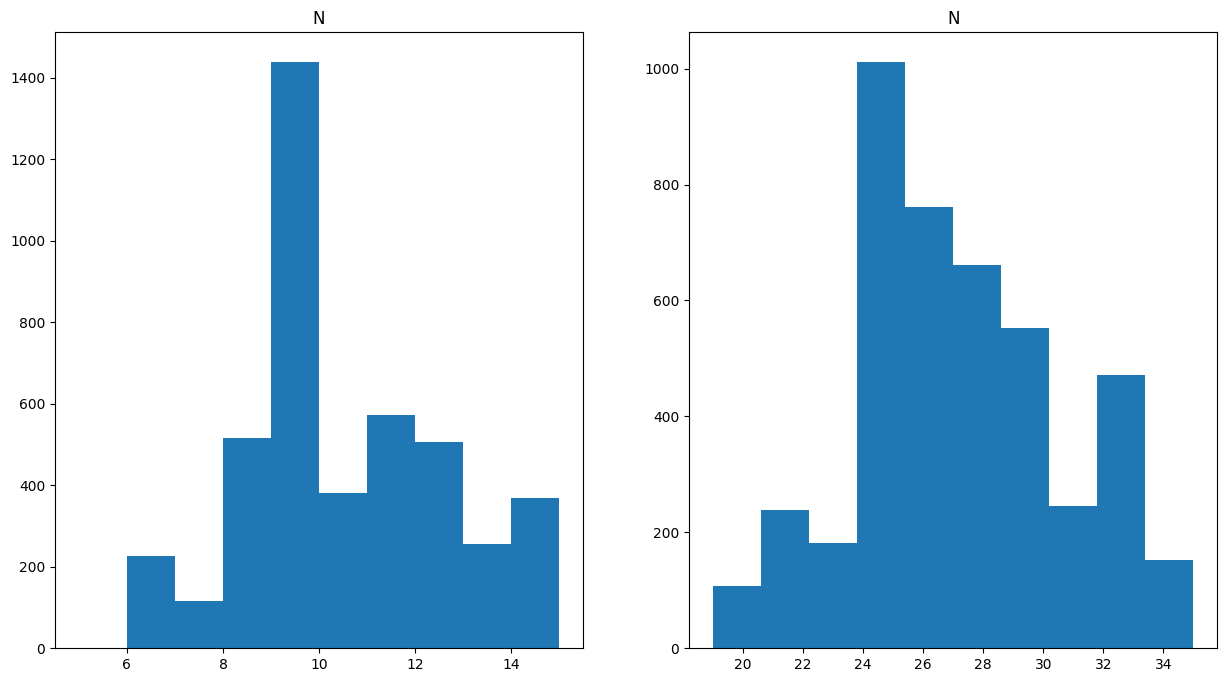

In [ ]:

# scaled no of cells in each spot between 5-15.
cells_at_spot = plot_histogram(N_cell2loc)
#cells_at_spot.to_csv(simulated_data_path + "simulated_cells_at_spot.csv")
print ("Generating simulated gene expression data")
adata = generate_expression(ann, sam, original_st_data, decon_matrix, cells_at_spot, ctp_var_names, m_g, spot_barcodes)

Downsampling the simulated datasets

Compute distance matrix
Sample UMI from Multi-variate Gaussian distribution
0.5050671320639292 1.8163958966697298


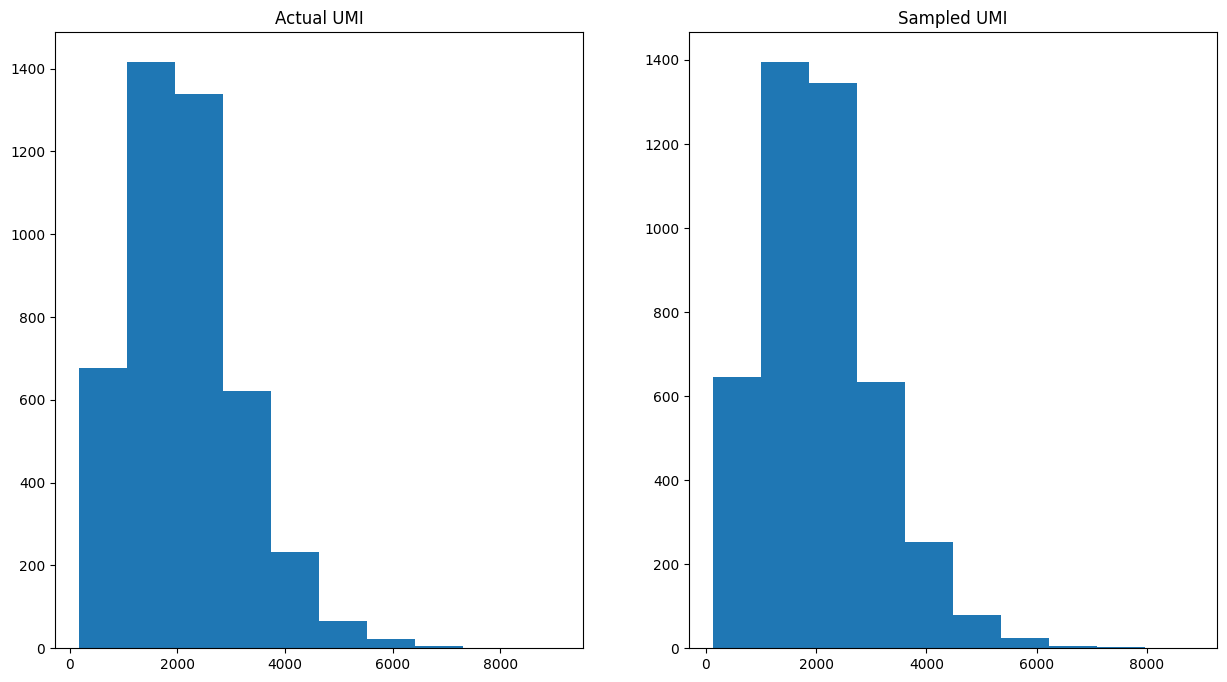

In [ ]:
print ("Compute distance matrix")
distance_matrix = compute_distane_matrix(num_spots, tissue_positions_list)

print ("Sample UMI from Multi-variate Gaussian distribution")
sampled_umi, original_umi_counts = sample_UMI(num_spots, distance_matrix, original_st_data, cov_matrix, scale_factor)

Scale Anndata
scaling  0.025484677667040788 2.3554850087601245
False


/content/spDDB/SynthST/Simulator_gene_expression/simulate_gene_expression.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  original_st_data.obs['umi_counts_actual'] = original_umi_counts
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/content/spDDB/SynthST/Simulator_gene_expression/simulate_gene_expression.py:179: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(original_st_data, basis = "spatial", color = ["umi_counts_actual", "umi_sampled"], cmap='Reds',


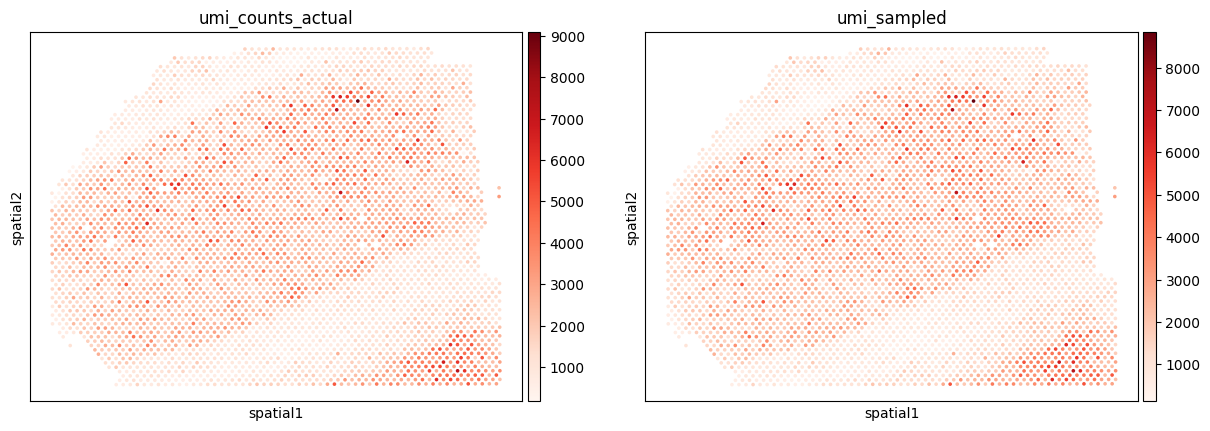

/content/spDDB/SynthST/Simulator_gene_expression/simulate_gene_expression.py:181: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(original_st_data, basis = "spatial", color = ["diff"], cmap='Spectral',


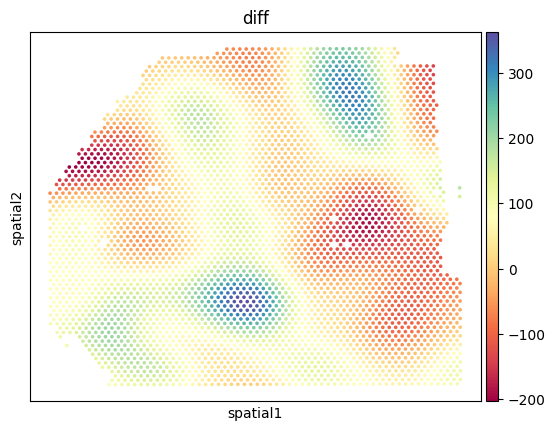

/content/spDDB/SynthST/Simulator_gene_expression/simulate_gene_expression.py:184: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(adata, basis = "spatial", color = ["umi_count_before_scaling", "umi_count_after_scaling"], cmap='Reds',


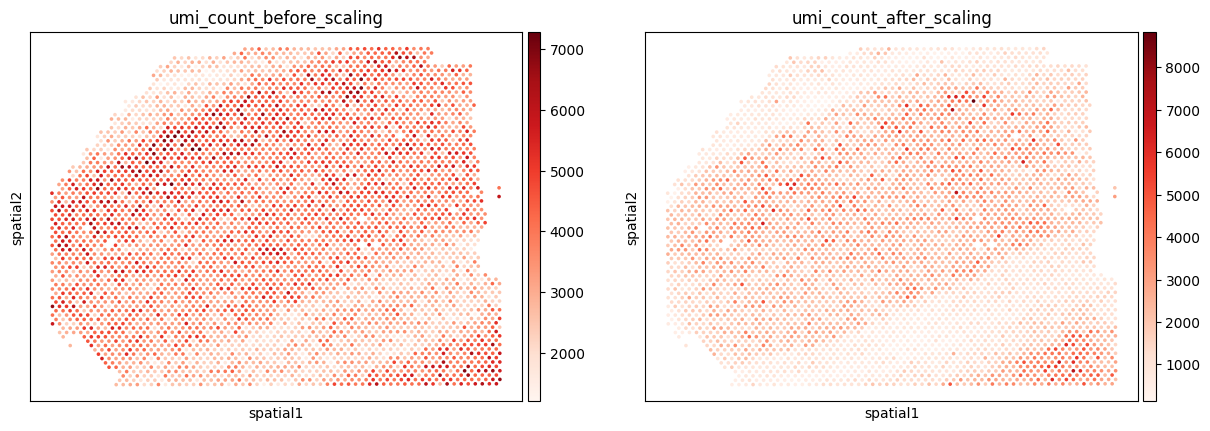

/content/spDDB/SynthST/Simulator_gene_expression/simulate_gene_expression.py:186: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.embedding(adata, basis = "spatial", color = ["diff"], cmap='Spectral',


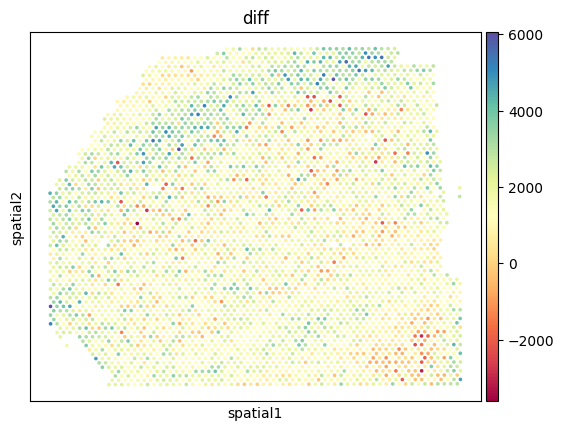

In [ ]:
print ("Scale Anndata")
adata = scale_anndata(adata, original_st_data, sampled_umi, original_umi_counts)

In [ ]:
adata.X = np.round(adata.X)
adata.X = adata.X.astype(np.uint64)
print (np.min(adata.X))

0


In [ ]:
print (adata)
adata.write_h5ad(simulated_data_path)

AnnData object with n_obs × n_vars = 4382 × 11403
    obs: 'in_tissue', 'array_row', 'array_col', 'scaling_factors', 'umi_count_before_scaling', 'umi_count_after_scaling', 'diff'
    uns: 'spatial'
    obsm: 'spatial'
